<a href="https://colab.research.google.com/github/RenzoLA26/Challenges/blob/main/LUNA%20RENZO_GALVAN%20LUIS_Challenge2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume independencia entre variables, lo cual no es totalmente realista en variables clínicas, pero igual puede funcionar bien.
2. En k-NN sin escalado, la glucosa dominaría la distancia por tener mayor rango de valores
3. En tamizaje de diabetes se prioriza el recall, para detectar la mayor cantidad de casos posibles
4. Con baja prevalencia (5%), Naive Bayes tendería a predecir más “no diabéticos”, aumentando el riesgo de falsos negativos.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] EDA + limpieza  ← ¿Qué haces aquí?
    │
    ▼
[ Paso B ] Test  ← ¿Aquí ya haces el split? ¿Por qué?
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Imputación  + Escalado  ← ¿Qué estimas SOLO con train?        │
    │                                                             │
    ▼                                                             │
[ Paso D ] Naive Bayes y k-NN  ← Entrenamiento de modelos            │
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] Precisión  ← Evaluación final
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [2]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = Path('/content/drive/patrones') / 'diabetes.csv'

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [4]:
df = pd.read_csv("diabetes.csv")

print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
  No diabética (0): 500 pacientes (65.1%)
  Diabética    (1): 268 pacientes (34.9%)


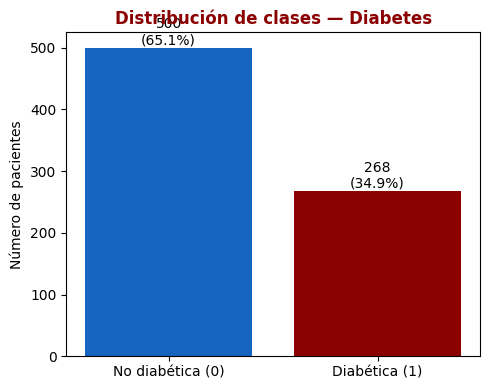

→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?
Rpta: Hay un gran desbalance entre una clase y otra.


In [6]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'
conteo = df['Outcome'].value_counts()
pct    = df['Outcome'].value_counts(normalize=True) * 100

print('Distribución de clases:')
print(f'  No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
ax.bar([0, 1], conteo.values, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
for i in range(len(conteo)):
    ax.text(i, conteo.values[i] + 5,
            f'{conteo.values[i]}\n({pct.values[i]:.1f}%)',
            ha='center')

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')
print("Rpta: Hay un gran desbalance entre una clase y otra.")

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [7]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [8]:
df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()
df_clean[cols_no_cero] = df_clean[cols_no_cero].replace(0, np.nan)

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

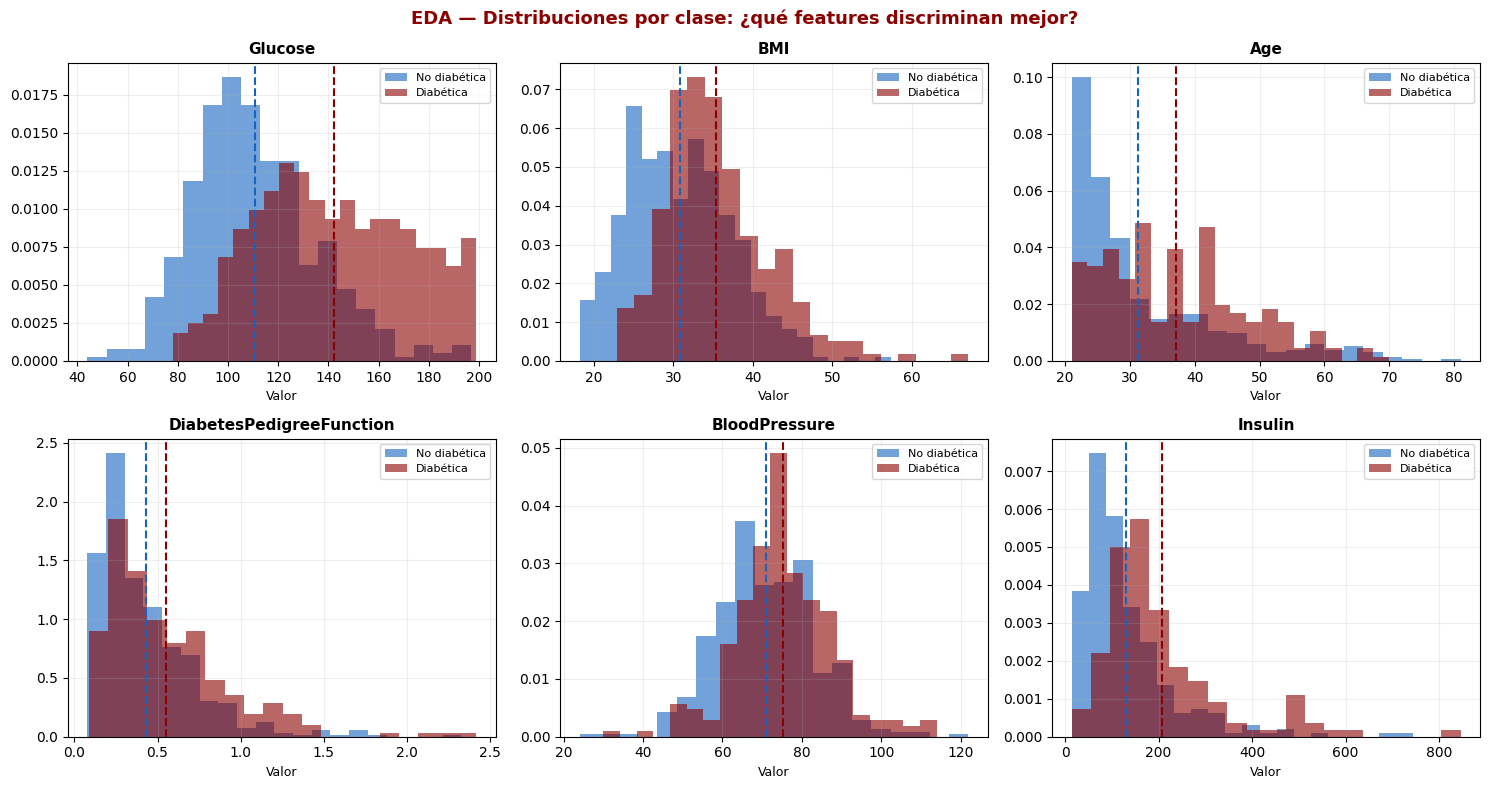

→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?
Rpta: Visualmente por el histograma y la linea de media -> Mayor separacion: Glucose,    Mayor solapamiento:DiabetesPedigreeFunction


In [9]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]

    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos (density=True) para clase 0 y clase 1
    # Usa alpha=0.6, UPCH_BLUE para clase 0, UPCH_RED para clase 1
    # Agrega una línea vertical con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()

        # Histograma
        ax.hist(valores, bins=20, density=True, alpha=0.6, color=color, label=label)

        # Línea de la media
        ax.axvline(valores.mean(), color=color, linestyle='--')

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?')
print("Rpta: Visualmente por el histograma y la linea de media -> Mayor separacion: Glucose,    Mayor solapamiento:DiabetesPedigreeFunction")

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

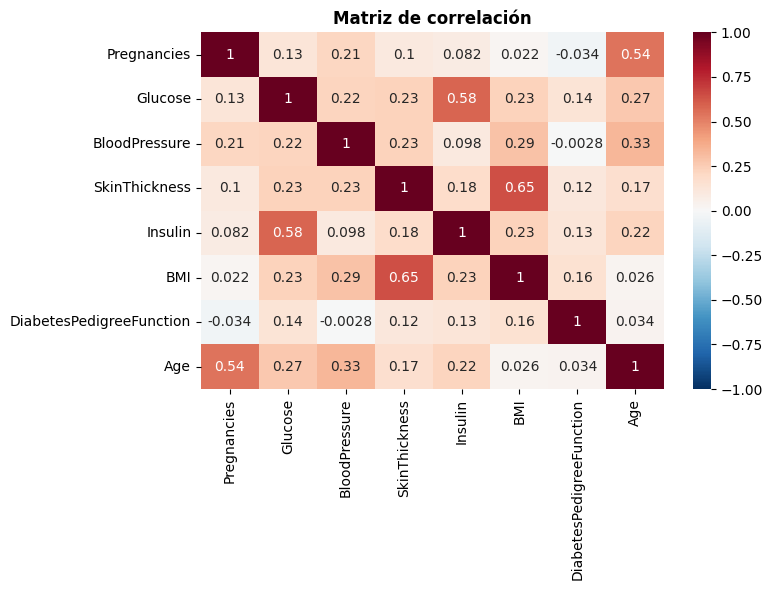

→ Identifica los pares de features con |correlación| > 0.5.
Rpta: Age-Pregnancies, Insuline-Glucose, BMI-SkinThickness
  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?
Correlaciones moderadas entre variables violan la hipótesis de independencia de Naive Bayes; sin embargo, el impacto suele ser limitado, ya que el modelo mantiene buen desempeño incluso con dependencias parciales entre features


In [10]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
#       y grafícala con seaborn heatmap. Incluye: cmap='RdBu_r', vmin=-1, vmax=1, annot=True

# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
corr = df_clean.drop(columns='Outcome').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, annot=True)

plt.title('Matriz de correlación', fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Identifica los pares de features con |correlación| > 0.5.')
print('Rpta: Age-Pregnancies, Insuline-Glucose, BMI-SkinThickness')
print('  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?')
print('Correlaciones moderadas entre variables violan la hipótesis de independencia de Naive Bayes; sin embargo, el impacto suele ser limitado, ya que el modelo mantiene buen desempeño incluso con dependencias parciales entre features')

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [11]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 8)  →  214 diabéticas (34.9%)
Test:  (154, 8)   →  54 diabéticas (35.1%)


In [12]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imputa los NaN con la MEDIANA de train (no de todo el dataset)
#       Aplica la mediana de train también al test

mediana_train = X_train.median()
X_train_imp   = X_train.fillna(mediana_train)
X_test_imp    = X_test.fillna(mediana_train)

print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum()}')
print(f'NaN en test  tras imputación: {np.isnan(X_test_imp).sum()}')

NaN en train tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
NaN en test  tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [13]:
# --- COMPLETA EL CÓDIGO ---
# TODO: escala con StandardScaler
#       - fit_transform sobre X_train_imp
#       - transform (sin fit) sobre X_test_imp

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: 0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [14]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
gnb = GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7013


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [15]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: divide X_train_sc / y_train en subconjuntos train_sub / val (80/20, estratificado)
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(X_train_sc, y_train, test_size=0.2, random_state=42, stratify=y_train)

# TODO 2: itera sobre k_values = [1, 3, 5, 7, 9, 11, 15]
#          guarda acc en train_sub y val para cada k
k_values = [1, 3, 5, 7, 9, 11,15]
acc_tr_list  = []
acc_val_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sub, y_tr_sub)

    acc_tr_list.append(accuracy_score(y_tr_sub, knn.predict(X_tr_sub)))
    acc_val_list.append(accuracy_score(y_val, knn.predict(X_val)))

# TODO 3: identifica k óptimo (argmax de acc_val_list)
k_optimo = k_values[np.argmax(acc_val_list)]
print(f'k óptimo = {k_optimo}  (val accuracy = {max(acc_val_list):.4f})')

k óptimo = 15  (val accuracy = 0.8211)


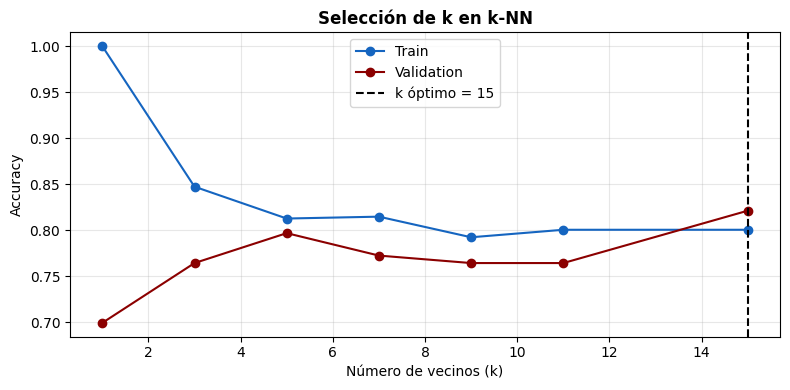

In [16]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica train vs val accuracy en función de k
# Incluye: línea vertical en k óptimo, leyenda, títulos, colores UPCH

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, acc_tr_list, marker='o', color=UPCH_BLUE, label='Train')
ax.plot(k_values, acc_val_list, marker='o', color=UPCH_RED, label='Validation')

# Línea vertical en k óptimo
ax.axvline(k_optimo, linestyle='--', color='black', label=f'k óptimo = {k_optimo}')

ax.set_title('Selección de k en k-NN', fontweight='bold')
ax.set_xlabel('Número de vecinos (k)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena k-NN final con k_optimo sobre TODO X_train_sc
#       predice sobre X_test_sc
knn_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_opt.fit(X_train_sc, y_train)

y_pred_knn = knn_opt.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'k-NN (k={k_optimo}) — Accuracy final en test: {acc_knn:.4f}')

k-NN (k=15) — Accuracy final en test: 0.7403


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

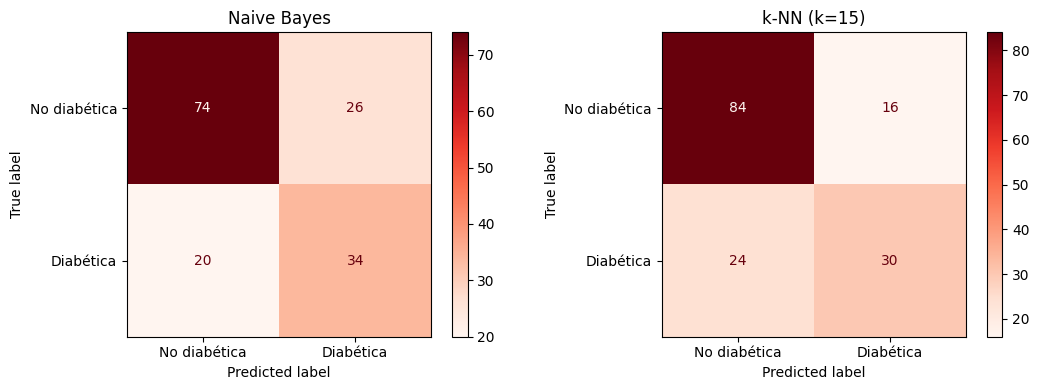

In [18]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica las dos matrices de confusión lado a lado (fig con 2 subplots)
# Usa ConfusionMatrixDisplay, cmap='Reds', labels=['No diabética', 'Diabética']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('Naive Bayes')

# k-NN
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['No diabética', 'Diabética'],
    cmap='Reds',
    ax=axes[1]
)
axes[1].set_title(f'k-NN (k={k_optimo})')

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [19]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula para ambos modelos: accuracy, precision, recall, f1
#       sobre la clase positiva (Diabética = 1)
#       imprime una tabla comparativa clara

metrics = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'k-NN'],
    'Accuracy': [accuracy_score(y_test, y_pred_gnb),accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_gnb),precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_gnb),recall_score(y_test, y_pred_knn)],
    'F1': [f1_score(y_test, y_pred_gnb),f1_score(y_test, y_pred_knn)]
})

print(metrics)

print('\n→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?')
print("Rpta: Naives Bayes. Es importante tener un alto recall, ya que esto te indica que es capaz de identificar correctamente la gran mayoría de los casos positivos reales de un conjunto de datos")

        Modelo  Accuracy  Precision    Recall        F1
0  Naive Bayes  0.701299   0.566667  0.629630  0.596491
1         k-NN  0.740260   0.652174  0.555556  0.600000

→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?
Rpta: Naives Bayes. Es importante tener un alto recall, ya que esto te indica que es capaz de identificar correctamente la gran mayoría de los casos positivos reales de un conjunto de datos


### Paso 7.3 — Gráfico comparativo de métricas

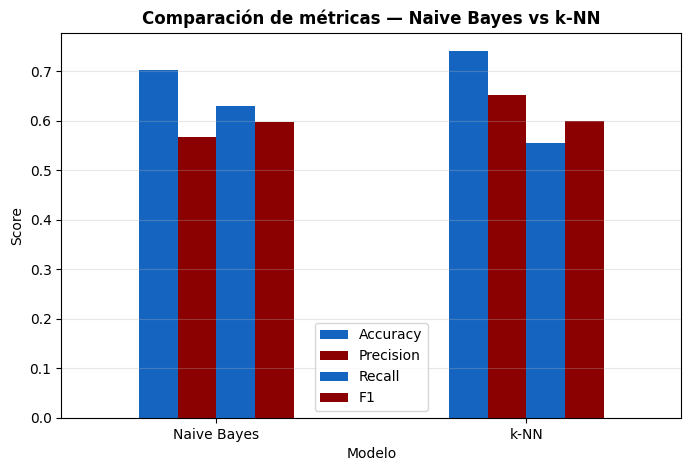

In [20]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica un bar chart comparando accuracy, precision, recall y F1
# para k-NN y Naive Bayes, con colores UPCH

metrics_plot = metrics.set_index('Modelo')

ax = metrics_plot.plot(kind='bar', figsize=(8,5), color=[UPCH_BLUE, UPCH_RED])

plt.title('Comparación de métricas — Naive Bayes vs k-NN', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

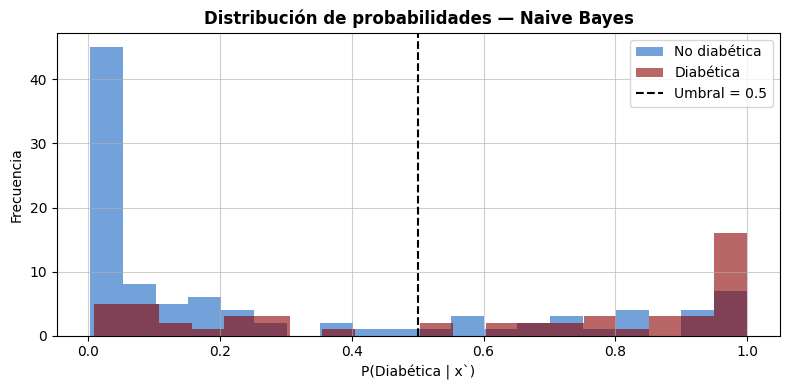

In [21]:
# Probabilidades posteriores de Naive Bayes
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: grafica el histograma de probabilidades P(Diabética | x)
#         diferenciando por clase real (y_test == 0 y y_test == 1)
#         con alpha=0.6, UPCH_BLUE y UPCH_RED
#         agrega una línea vertical en 0.5 (umbral por defecto)

fig, ax = plt.subplots(figsize=(8, 4))
# Clase 0
ax.hist(proba_gnb[y_test==0], bins=20, alpha=0.6, color=UPCH_BLUE, label='No diabética')

# Clase 1
ax.hist(proba_gnb[y_test==1], bins=20, alpha=0.6, color=UPCH_RED, label='Diabética')

# Línea de umbral
ax.axvline(0.5, color='black', linestyle='--', label='Umbral = 0.5')

ax.set_title('Distribución de probabilidades — Naive Bayes', fontweight='bold')
ax.set_xlabel('P(Diabética | x`)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(alpha=0.6)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision en ambos casos vs el umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1

print('Umbral | Precision | Recall | F1')

for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral = (proba_gnb >= umbral).astype(int)

    prec = precision_score(y_test, y_pred_umbral)
    rec  = recall_score(y_test, y_pred_umbral)
    f1   = f1_score(y_test, y_pred_umbral)

    print(f'{umbral:.2f}   | {prec:.3f}     | {rec:.3f}  | {f1:.3f}')

print()
print('→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')
print("Recomendaría un umbral de 0.35, ya que maximiza el recall, lo cual es fundamental en programas de tamizaje donde el objetivo principal es no dejar casos sin detectar, incluso a costa de un aumento en falsos positivos")

Umbral | Precision | Recall | F1
0.35   | 0.538     | 0.648  | 0.588
0.50   | 0.567     | 0.630  | 0.596
0.65   | 0.588     | 0.556  | 0.571

→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?
Recomendaría un umbral de 0.35, ya que maximiza el recall, lo cual es fundamental en programas de tamizaje donde el objetivo principal es no dejar casos sin detectar, incluso a costa de un aumento en falsos positivos


---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [23]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)
gnb_low_prev = GaussianNB(priors=[0.95, 0.05])
gnb_low_prev.fit(X_train_imp, y_train)

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp = gnb_low_prev.predict(X_test_imp)


print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:               Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f}')
print()
print('📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print('Cuando la prevalencia baja, el recall disminuye.')

Comparación de priors:
  Prior original (~35% diabetes):  Recall=0.6296  Precision=0.5667
  Prior 5% diabetes:               Recall=0.3519  Precision=0.6333

📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?
   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).


---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | Naive Bayes | Recall | ___ |
| Confirmación diagnóstica en hospital | k-NN | Precisión | ___ |
| Sistema embebido en glucómetro portátil | Naive Bayes | Accuracy | ___ |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1. La independencia entre variables no se cumple, ya que observamos correlaciones entre features. Se detecto en la matriz de correlación.
2. k-NN requiere calcular distancias con todos los datos, por lo que con 50,000 pacientes y 200 variables sería computacionalmente costoso y lento.
3. La sensibilidad (recall) y también la especificidad, ya que permiten evaluar la capacidad del modelo para detectar enfermos y evitar falsos positivos, lo cual es clave en decisiones médicas.

In [24]:
# Resumen ejecutivo final
print('=' * 60)
print('          RESUMEN DEL CHALLENGE 2')
print('=' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()
print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_optimo})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}       '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}       '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')

          RESUMEN DEL CHALLENGE 2
Dataset: Pima Indians Diabetes  (N=768, d=8)
Prevalencia en test: 35.1%

Modelo               Accuracy     Recall       Precision    F1
------------------------------------------------------------
k-NN (k=15)          0.7403       0.5556       0.6522       0.6000
Naive Bayes          0.7013       0.6296       0.5667       0.5965

Archivos generados:
  distribucion_diabetes.png   eda_diabetes.png
  knn_seleccion_k_diabetes.png cm_comparacion.png
  comparacion_metricas.png    histograma_proba.png
